Loading final dataset...
Training Random Forest Model (Handling Imbalanced Data)...


/var/folders/kc/t3sn0bvn6djgck1vl99fwf1c0000gn/T/com.apple.shortcuts.mac-helper/ipykernel_15226/663771507.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=importances.values, y=importances.index, palette='magma')


ML analysis complete! Graph saved to ../images/ml_feature_importance.png


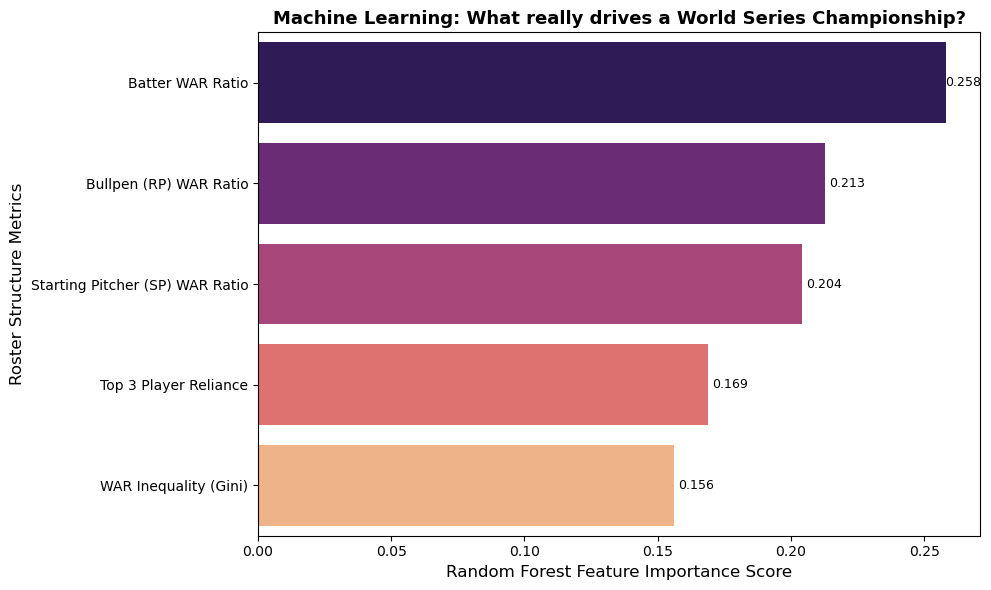

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

print("Loading final dataset...")
df = pd.read_csv('../data/processed_data/final_team_data.csv')

# 2020 Season dropped due to a shortened season due to COVID pandemic.
df = df[df['Season'] != 2020].copy()

# Feature Engineering: Positional WAR Ratios
df['Batter_Ratio'] = df['Batter_WAR'] / df['Total_WAR']
df['SP_Ratio'] = df['SP_WAR'] / df['Total_WAR']
df['RP_Ratio'] = df['RP_WAR'] / df['Total_WAR']

# Fill NA just in case a team had 0 total WAR (impossible, but good practice)
df = df.fillna(0)

# Define Features (X) and Target (y)
features = ['Gini_Coefficient', 'Top3_WAR_Ratio', 'Batter_Ratio', 'SP_Ratio', 'RP_Ratio']
X = df[features]
y = df['WS_Winner']

# MACHINE LEARNING: Random Forest Classifier

# class_weight='balanced' to solve the problem of imbalanced data - there are only 14 champions and 406 non-champions.
# n_estimators = 200 and random_state = 42 for credibility
print("Training Random Forest Model (Handling Imbalanced Data)...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X, y)

# Extract Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

# Rename features for better readability in the plot
pretty_names = {
    'Gini_Coefficient': 'WAR Inequality (Gini)',
    'Top3_WAR_Ratio': 'Top 3 Player Reliance',
    'RP_Ratio': 'Bullpen (RP) WAR Ratio',
    'SP_Ratio': 'Starting Pitcher (SP) WAR Ratio',
    'Batter_Ratio': 'Batter WAR Ratio'
}
importances.index = importances.index.map(pretty_names)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=importances.values, y=importances.index, palette='magma')

for i, container in enumerate(ax.containers):
    pad_val = 0 if i == 0 else 3
    ax.bar_label(container, fmt='%.3f', padding=pad_val, fontsize=9)


plt.title('Machine Learning: What really drives a World Series Championship?', fontsize=13, fontweight='bold')
plt.xlabel('Random Forest Feature Importance Score', fontsize=12)
plt.ylabel('Roster Structure Metrics', fontsize=12)

# Save and show
save_ml_path = '../images/ml_feature_importance.png'
plt.tight_layout()
plt.savefig(save_ml_path, dpi=300)
print(f"ML analysis complete! Graph saved to {save_ml_path}")
plt.show()